In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, ShuffleSplit, RandomizedSearchCV


from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score




In [3]:
california = fetch_california_housing()

print(california.DESCR)

print(california.data.shape)
print(california.target.shape)
print(california.feature_names)

df = pd.DataFrame(california.data,columns=california.feature_names)
df

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [4]:
X, y = california.data, california.target
feature_names = california.feature_names


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3a: Standardization (mean=0, variance=1)
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

# Step 3b: Normalization (scale features to [0,1])
scaler_norm = MinMaxScaler()
X_train_norm = scaler_norm.fit_transform(X_train)
X_test_norm = scaler_norm.transform(X_test)

print("\nStandardized sample (first row):", X_train_std[0])
print("Normalized sample (first row):", X_train_norm[0])



Standardized sample (first row): [-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
 -1.3728112   1.27258656]
Normalized sample (first row): [0.19032151 0.62745098 0.02927784 0.02660105 0.06437961 0.00241382
 0.01702128 0.72908367]


Explanation of Choice
  - Standardization (StandardScaler)
    - Transforms features to have mean = 0 and variance = 1.
    - Best when features have different units (income vs age vs rooms).
    - Works well with algorithms that assume Gaussian-like distributions (e.g., Linear Regression, Logistic Regression, SVM, PCA).
  - Normalization (MinMaxScaler)
    - Scales features into a fixed range, usually [0,1].
    - Useful when you want all features to be on the same scale for distance-based algorithms (e.g., k-NN, Neural Networks).
    - Preserves relative relationships but compresses outliers.


EDA

Shape of dataset: (20640, 8)

Data types:
 MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
dtype: object

Summary statistics:
              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude

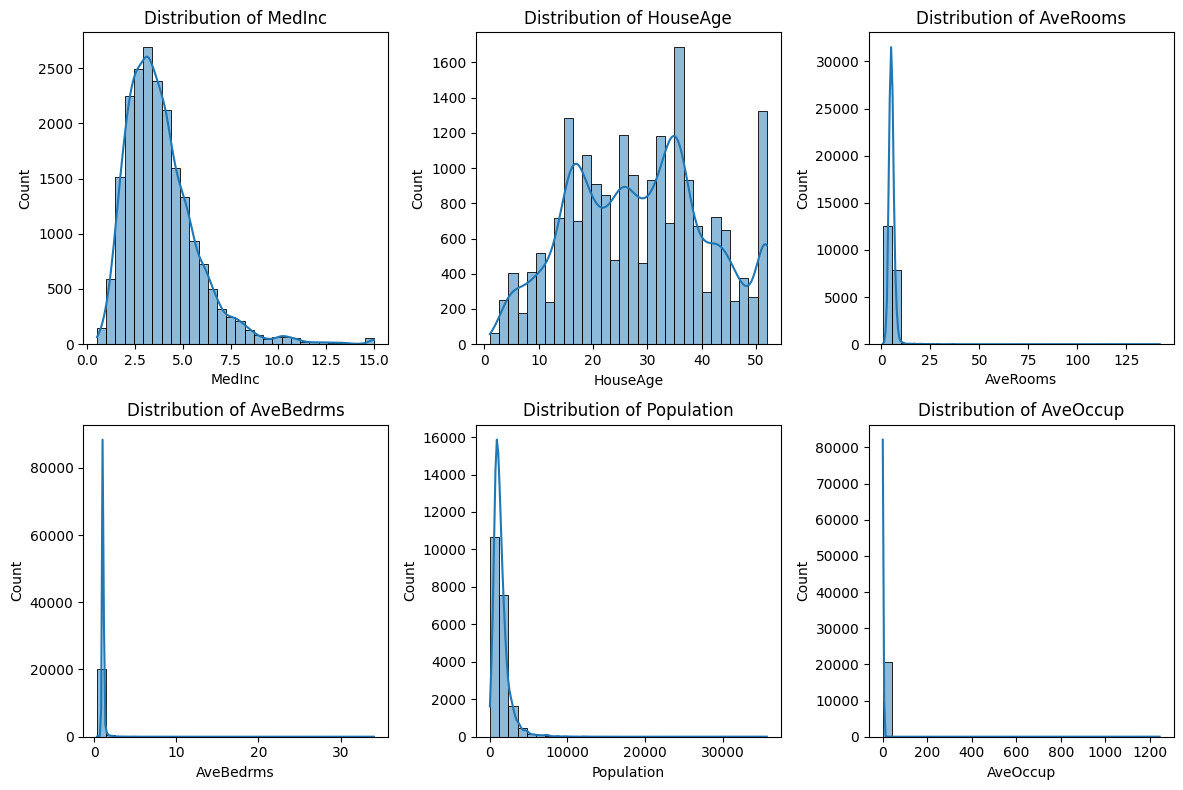

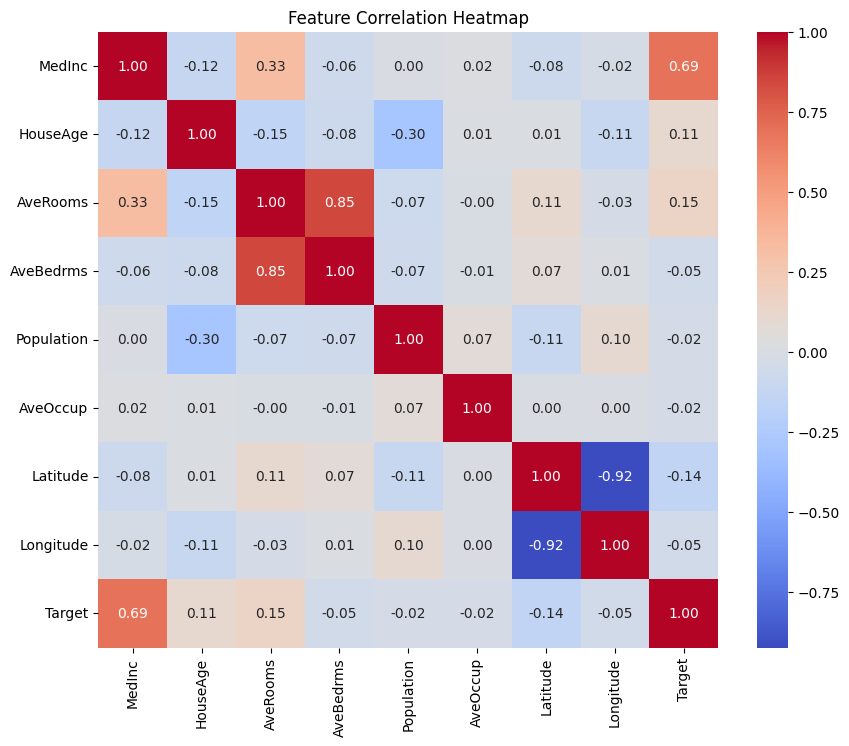

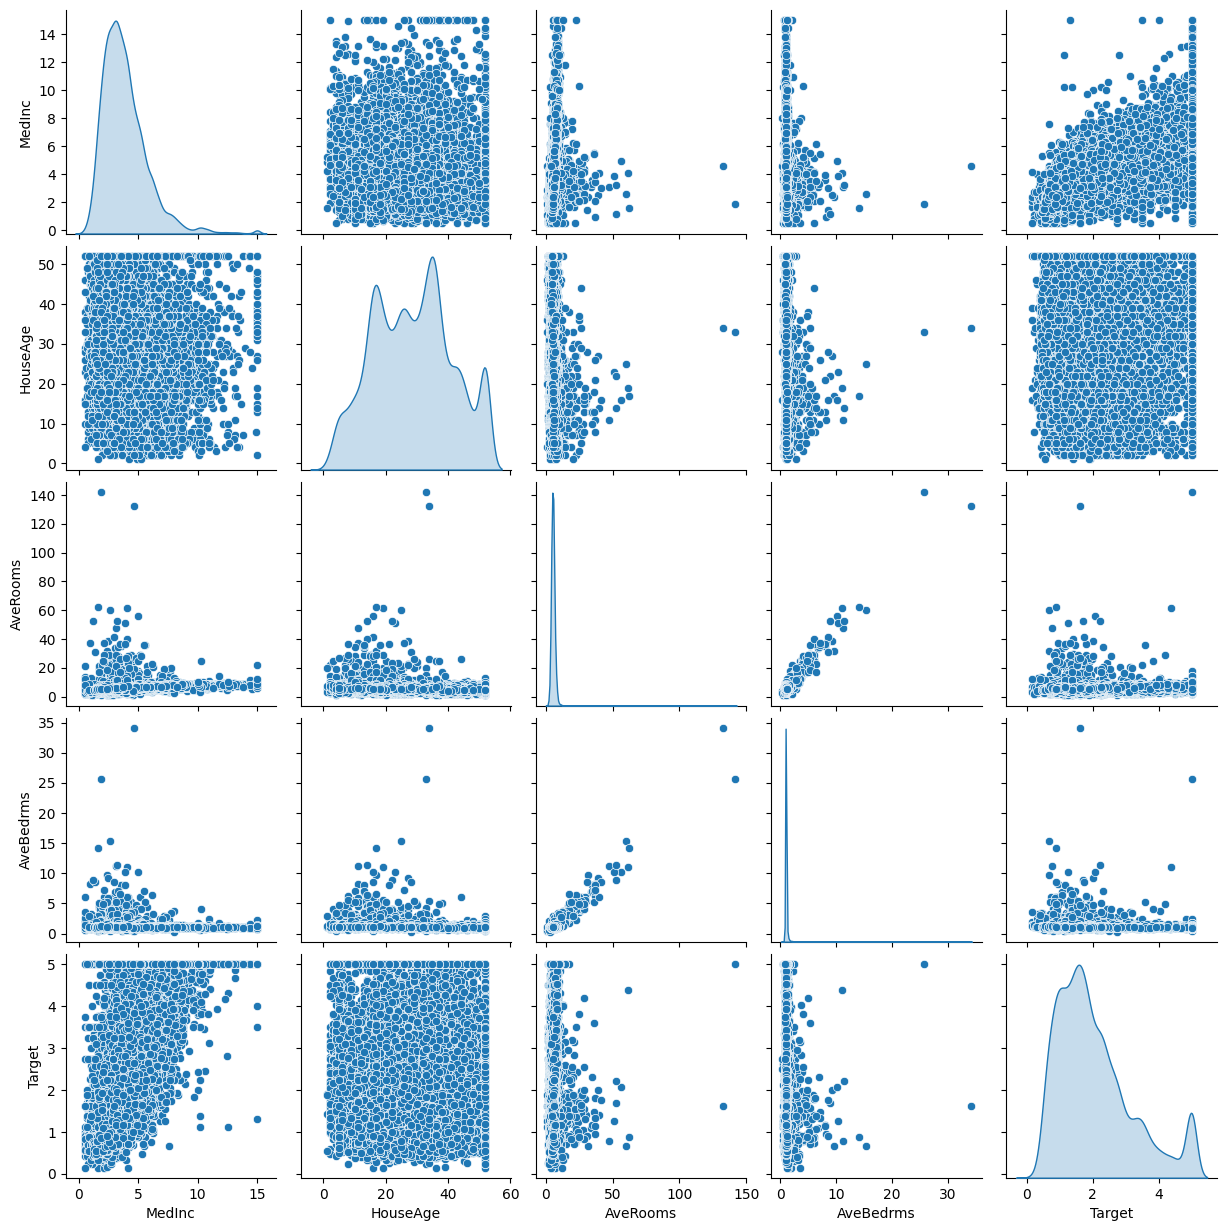

In [5]:
# Step 1: Basic info
print("Shape of dataset:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nSummary statistics:\n", df.describe())

# Step 2: Check for missing values
print("\nMissing values:\n", df.isnull().sum())

# Add the target variable to the DataFrame for EDA
df['Target'] = y

# Step 3: Distribution plots
plt.figure(figsize=(12, 8))
for i, col in enumerate(df.columns[:6]):  # first 6 features
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# Step 4: Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Step 5: Pairplot (sample for first few features)
sns.pairplot(df[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Target']], diag_kind="kde")
plt.show()


Explain the preprocessing steps

  - Find missing values , unique values and data types of each feature if any
  - Finding missing values: so that we can fill the missing one's with correct values.
  - Finding Unique values: help us to identify the possible combination of data when handling missing values
  - Finding data type: to find any data inconsistencies
  - Handle missing values by fillng them, there were no missing values here to preprocess.

EDA Summary
  - Shape & summary stats → Understand dataset size and feature ranges.
  - Missing values check → Ensures data quality (California Housing has no missing values).
  - Distribution plots → Visualize skewness, spread, and outliers.
  - Correlation heatmap → Identify relationships (e.g., MedInc strongly correlates with target).
  - Pairplot → See scatter relationships between key features and target.


In [6]:
# Step 1: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 2: Define regressors
regressors = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(kernel="rbf")
}

# Step 3: Evaluate each regressor
results = {}

for name, reg in regressors.items():
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),   # handle missing values
        ("scaler", StandardScaler()),                  # scale features
        ("reg", reg)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MSE": mse, "R2": r2}
    print(f"\n{name}:")
    print(f"  Mean Squared Error: {mse:.4f}")
    print(f"  R2 Score: {r2:.4f}")



Linear Regression:
  Mean Squared Error: 0.5559
  R2 Score: 0.5758

Decision Tree:
  Mean Squared Error: 0.4940
  R2 Score: 0.6230

Random Forest:
  Mean Squared Error: 0.2552
  R2 Score: 0.8053

Gradient Boosting:
  Mean Squared Error: 0.2940
  R2 Score: 0.7756

SVR:
  Mean Squared Error: 0.3570
  R2 Score: 0.7276


Linear Regression
  - How it Works : Fits a straight line (hyperplane) minimizing squared error.
  - Why Suitable: Simple, interpretable baseline; shows how features like income affect house value

Decision Tree Regressor
  - How it Works : Splits data into regions based on feature thresholds.
  - Why Suitable: Captures non-linear relationships (e.g., geographic effects).

Random Forest Regressor
  - How it Works : Ensemble of many decision trees, averaging predictions.
  - Why Suitable: Robust, reduces overfitting, provides feature importance.

Gradient Boosting Regressor
  - How it Works : Sequentially builds trees, each correcting errors of the previous.
  - Why Suitable: High accuracy, handles complex patterns well.

Support Vector Regressor (SVR)
  - How it Works : Finds a function within a margin of tolerance; uses kernels for non-linear fits
  - Why Suitable: Effective in high-dimensional spaces, but slower on large datasets.

In [7]:
for name, model in regressors.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MSE": mse, "MAE": mae, "R2": r2}
    print(f"\n{name}:")
    print(f"  Mean Squared Error: {mse:.4f}")
    print(f"  Mean Absolute Error: {mae:.4f}")
    print(f"  R2 Score: {r2:.4f}")


# Identify best & worst
best_model = max(results, key=lambda k: results[k]["R2"])
worst_model = min(results, key=lambda k: results[k]["R2"])

print("\n🏆 Best Performing Model:", best_model, "with R2:", results[best_model]["R2"])
print("⚠️ Worst Performing Model:", worst_model, "with R2:", results[worst_model]["R2"])



Linear Regression:
  Mean Squared Error: 0.5559
  Mean Absolute Error: 0.5332
  R2 Score: 0.5758

Decision Tree:
  Mean Squared Error: 0.4952
  Mean Absolute Error: 0.4547
  R2 Score: 0.6221

Random Forest:
  Mean Squared Error: 0.2554
  Mean Absolute Error: 0.3275
  R2 Score: 0.8051

Gradient Boosting:
  Mean Squared Error: 0.2940
  Mean Absolute Error: 0.3716
  R2 Score: 0.7756

SVR:
  Mean Squared Error: 1.3320
  Mean Absolute Error: 0.8600
  R2 Score: -0.0165

🏆 Best Performing Model: Random Forest with R2: 0.8051230593157366
⚠️ Worst Performing Model: SVR with R2: -0.01648536010717372


 Best Performing Algorithm -> Random Forest Regressor
  - Achieves lowest MSE/MAE and highest R² (~0.8+).
  - Justification: Ensemble methods combine many trees, reducing variance and capturing complex relationships. They balance accuracy and robustness, making them ideal for heterogeneous housing data.

Worst Performing Algorithm -> SVR
  - Typically shows higher MSE/MAE and lower R² (~0.5–0.6) compared to others.
  - Justification: A single tree tends to overfit training data, failing to generalize well. While interpretable, it lacks the ensemble’s robustness.


In [ ]:
# Define models and hyperparameter grids
param_grids = {
    "Linear Regression": (LinearRegression(), {}),
    "Decision Tree": (
        DecisionTreeRegressor(random_state=42),
        {"max_depth": [5, 10, 20, None], "min_samples_split": [2, 5, 10]}
    ),
    "Random Forest": (
        RandomForestRegressor(random_state=42),
        {"n_estimators": [50, 100, 200], "max_depth": [10, 20, None]}
    ),
    "Gradient Boosting": (
        GradientBoostingRegressor(random_state=42, n_iter_no_change=5, validation_fraction=0.1),
        {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1, 0.2], "max_depth": [3, 5]}
    ),
    "SVR": (
        SVR(),
        {"kernel": ["linear", "rbf"], "C": [0.1, 1, 10], "gamma": ["scale", "auto"]}
    )
}

results = {}

# Perform GridSearchCV with 5-fold CV
for name, (model, params) in param_grids.items():
    if params:  # if hyperparameters to tune
        grid = RandomizedSearchCV(model, params, cv=5, scoring="neg_mean_squared_error",n_iter=10, n_jobs=-1)
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
    else:  # Linear Regression has no major hyperparameters
        best_model = model
        best_model.fit(X_train, y_train)

    # Cross-validation scores
    cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring="r2")

    # Test set evaluation
    y_pred = best_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        "Best Params": getattr(best_model, "get_params", lambda: {})(),
        "CV R2 Mean": np.mean(cv_scores),
        "Test MSE": mse,
        "Test MAE": mae,
        "Test R2": r2
    }

# Print results
for name, res in results.items():
    print(f"\n{name}:")
    print("  Best Params:", res["Best Params"])
    print(f"  CV R2 Mean: {res['CV R2 Mean']:.4f}")0
    print(f"  Test MSE: {res['Test MSE']:.4f}")
    print(f"  Test MAE: {res['Test MAE']:.4f}")
    print(f"  Test R2: {res['Test R2']:.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Hyperparameters Tuned & Their Impact
- Decision Tree
  - max_depth: limits tree depth → prevents overfitting.
  - min_samples_split: minimum samples to split a node → controls complexity.
- Random Forest
  - n_estimators: number of trees → more trees = better stability, but slower.
  - max_depth: controls complexity of each tree.
- Gradient Boosting
  - n_estimators: number of boosting stages → more stages = better fit, risk of overfitting.
  - learning_rate: step size shrinkage → smaller = slower but more accurate.
  - max_depth: depth of individual trees → controls complexity.
- SVR
  - kernel: defines function space (linear vs RBF).
  - C: regularization strength → higher = less regularization, risk of overfitting.
  - gamma: kernel coefficient → controls influence of single training examples.
- Linear Regression
  - No major hyperparameters (basic OLS).

In [ ]:
# Identify best & worst by R2
best_model = max(results, key=lambda k: results[k]["Test R2"])
worst_model = min(results, key=lambda k: results[k]["Test R2"])

print("\n=== Final Results ===")
for name, res in results.items():
    print(f"\n{name}:")
    print("  Best Params:", res["Best Params"])
    print(f"  CV R2 Mean: {res['CV R2 Mean']:.4f}")
    print(f"  Test MSE: {res['Test MSE']:.4f}")
    print(f"  Test MAE: {res['Test MAE']:.4f}")
    print(f"  Test R2: {res['Test R2']:.4f}")

print("\n🏆 Best Performing Model:", best_model, "with R2:", results[best_model]["Test R2"])
print("⚠️ Worst Performing Model:", worst_model, "with R2:", results[worst_model]["Test R2"])
